# 02 · Attendance nowcast

**Goal:** at every hour of the day, give the best estimate of today's **final**
attendance, with an honest uncertainty band, starting from the pre-open forecast and
tightening it as gate counts arrive.

This is notebook 01's parcel-on-a-scale, with three changes:

| Notebook 01 | This notebook |
| --- | --- |
| true parcel weight | today's final attendance `x` |
| rough prior (2.0 ± 0.2 kg) | the pre-open forecast and its historical error variance `P₀` |
| a scale reading `z` with fixed noise `R` | the hourly **implied final total** `z_t = C_t / f_t`, whose noise `R_t` *changes through the day* |

### Symbols

| Symbol | Meaning |
| --- | --- |
| `x`, `P` | estimated final attendance and its variance |
| `C_t` | cumulative gate count at clock hour `t` |
| `f_t` | historical share of the day's entries that have arrived by hour `t` |
| `z_t` | implied final total, `C_t / f_t` |
| `R_t` | measurement noise variance of `z_t` at hour `t` |
| `Q` | process noise: room for surprises between readings (a storm, say) |

### ⚠️ Simulated data

**Every number in this notebook is SIMULATED.** The park is a fictional park in
Tampa, Florida. Its daily totals, hourly gate counts and weather come from
`nowcast/simulate.py`. It sits in Florida so the Attendance-Projections features
(Florida weather, US/FL holidays, calendar) carry over.

The data lives in a SQL database. Every table has a `source` column, `simulation` or
`production`, and every loader must be told which one to read. When real gate data
arrives, it is loaded with `source = 'production'` and this notebook runs unchanged
after flipping one variable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nowcast import db
from nowcast.arrivals import estimate_curve
from nowcast.forecast import same_weekday_forecast, relative_error_sd
from nowcast.kalman import predict, update
from nowcast.noise import implied_errors, noise_by_hour, relative_R
from nowcast.runner import nowcast_days
from nowcast.style import COLORS, apply_style

apply_style()
pd.set_option("display.precision", 3)

## 1. Load the data from the database

`db.get_engine()` connects to the database named in the `NOWCAST_DB_URL` environment
variable. If that isn't set, it uses a local SQLite file (`data/nowcast.db`), so
nothing needs installing. `ensure_simulated_data` creates the tables and fills them
with the simulated park the first time it runs.

**`SOURCE` is the one switch between simulated and real data.**

In [2]:
SOURCE = "simulation"          # change to "production" once real rows are loaded

engine = db.get_engine()
PARK_ID = db.ensure_simulated_data(engine)   # no-op if already built; never touches production rows

daily = db.load_daily(engine, PARK_ID, SOURCE)     # one row per day: final attendance
hourly = db.load_hourly(engine, PARK_ID, SOURCE)   # one row per day and hour: cumulative count

print(f"database: {engine.url}")
print(f"park: {PARK_ID}   source: {SOURCE}")
print(f"{len(daily)} days, {daily.visit_date.min():%Y-%m-%d} to {daily.visit_date.max():%Y-%m-%d}")
hourly.head(9)

database: sqlite:////home/user/Attendance-Nowcast/data/nowcast.db
park: SIM_TAMPA_FL   source: simulation
1096 days, 2022-01-01 to 2024-12-31


,park_id,visit_date,hour,cumulative_entries,source
0,SIM_TAMPA_FL,2022-01-01,10,954,simulation
1,SIM_TAMPA_FL,2022-01-01,11,2478,simulation
2,SIM_TAMPA_FL,2022-01-01,12,4306,simulation
3,SIM_TAMPA_FL,2022-01-01,13,5316,simulation
4,SIM_TAMPA_FL,2022-01-01,14,5878,simulation
5,SIM_TAMPA_FL,2022-01-01,15,6234,simulation
6,SIM_TAMPA_FL,2022-01-01,16,6358,simulation
7,SIM_TAMPA_FL,2022-01-01,17,6430,simulation
8,SIM_TAMPA_FL,2022-01-01,18,6444,simulation


Each day has nine readings, at 10:00, 11:00, … 18:00 (the park opens at 9:00 and
closes at 18:00). `cumulative_entries` only ever goes up, and the 18:00 value
equals that day's `attendance`.

Below, a week of **simulated** days, each drawn as a share of its own final total so
that busy and quiet days can be compared. They follow the same broad shape (slow
first hour, late-morning surge, flat afternoon) but no two are identical. The 18:00
point of each line is 100% by definition.

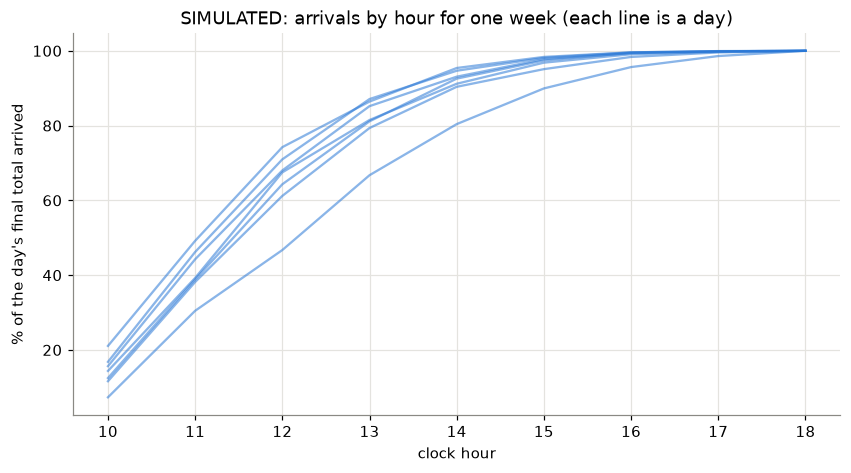

In [3]:
week = hourly[(hourly.visit_date >= "2023-05-01") & (hourly.visit_date < "2023-05-08")]
week = week.merge(daily[["visit_date", "attendance"]], on="visit_date")

fig, ax = plt.subplots()
for day, g in week.groupby("visit_date"):
    ax.plot(g.hour, 100 * g.cumulative_entries / g.attendance, color=COLORS["estimate"], alpha=0.55, lw=1.5)
ax.set_xlabel("clock hour")
ax.set_ylabel("% of the day's final total arrived")
ax.set_title("SIMULATED: arrivals by hour for one week (each line is a day)")
plt.show()

## 2. Split history from "the future"

To test fairly, everything the filter learns (arrival curve, noise levels, forecast
error) comes from **2022–2023**. We then score it on **2024**, a year it never
learned from.

In [4]:
TEST_START = "2024-01-01"
is_train = daily.visit_date < TEST_START
train_daily = daily[is_train]
train_hourly = hourly[hourly.visit_date < TEST_START]
print(f"train days: {is_train.sum()}   test days: {(~is_train).sum()}")

train days: 730   test days: 366


## 3. The arrival curve `f_t`

On a past day we know the final total, so we can compute what share had arrived by
each hour. Averaging those shares over all training days gives `f_t`:

$$f_t = \text{average over past days of } \frac{C_t}{\text{final total}}$$

*"By 12:00, on average, about 60% of the day's guests are in."* It reaches exactly 1
at closing.

hour
10    0.127
11    0.372
12    0.615
13    0.794
14    0.902
15    0.959
16    0.985
17    0.996
18    1.000


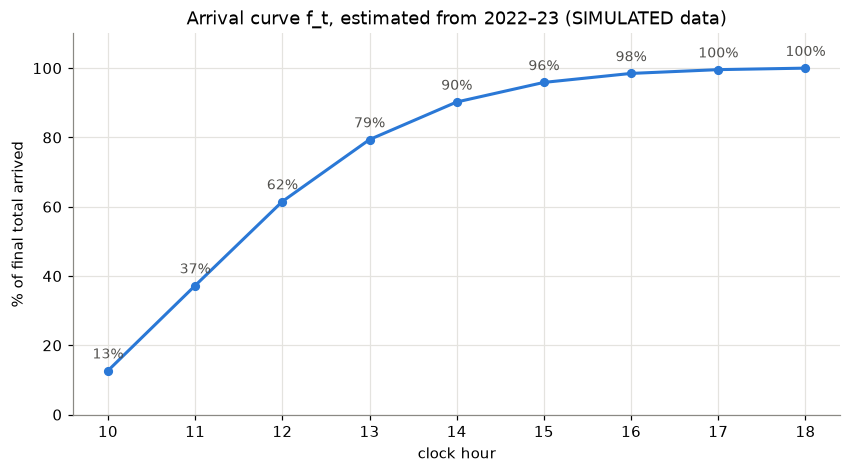

In [5]:
f = estimate_curve(train_hourly, train_daily)
print(f.round(3).to_string())

fig, ax = plt.subplots()
ax.plot(f.index, 100 * f.values, color=COLORS["estimate"], marker="o")
for hour, share in f.items():
    ax.annotate(f"{share:.0%}", (hour, 100 * share), textcoords="offset points", xytext=(0, 8),
                ha="center", color=COLORS["muted"], fontsize=9)
ax.set_ylim(0, 110)
ax.set_xlabel("clock hour")
ax.set_ylabel("% of final total arrived")
ax.set_title("Arrival curve f_t, estimated from 2022–23 (SIMULATED data)")
plt.show()

## 4. Turning a gate count into a measurement: `z_t = C_t / f_t`

The filter's state is the *final* total, but at 11:00 we only see the count so far.
To compare like with like, we scale it up:

$$z_t = \frac{C_t}{f_t}$$

*"If 1,500 guests are in by 11:00 and usually 37% arrive by then, the day is heading
for about 1,500 / 0.37 ≈ 4,050."*

This is a *measurement of the final total*, and it is noisy, especially early. At
10:00, `f_t ≈ 0.13`, so the count is multiplied by about 8, and any wobble is
multiplied by 8 too. We measure that noise on the training days, where the true
final total is known:

* `rel_sd`: the standard deviation of `z_t / final − 1` at each hour (e.g. 0.26 = ±26%)
* `rel_bias`: its average. On the training days this is exactly 0 by construction,
  because `f_t` *is* the average share; on new days it will only be close to 0.

In [6]:
errors = implied_errors(train_hourly, train_daily, f)
noise = noise_by_hour(errors)
noise[["rel_bias", "rel_sd"]].round(3)

,rel_bias,rel_sd
hour,,
10,0.0,0.265
11,0.0,0.197
12,-0.0,0.141
13,0.0,0.098
14,-0.0,0.059
15,-0.0,0.032
16,0.0,0.015
17,-0.0,0.006
18,0.0,0.000


The noise falls from about ±26% at 10:00 to about ±3% at 15:00, and to 0 at 18:00,
where the count *is* the final total.

That gives our measurement noise. Because a busy Saturday wobbles by more guests
than a quiet Tuesday, we keep it *relative* and scale it by the current estimate:

$$R_t = (s_t \times x^-)^2$$

*"At hour t, the implied total is typically off by `s_t` × today's size; square it
to get a variance."* (`R_t` never drops below a tiny floor, so the gain stays
strictly below 1.)

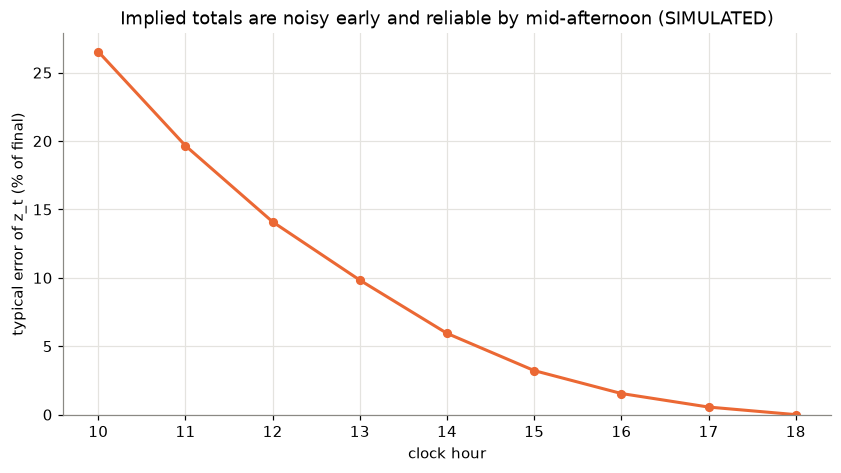

In [7]:
R = relative_R(noise["rel_sd"])     # a function: R(hour, x_prior) -> variance

fig, ax = plt.subplots()
ax.plot(noise.index, 100 * noise["rel_sd"], color=COLORS["measurement"], marker="o")
ax.set_xlabel("clock hour")
ax.set_ylabel("typical error of z_t (% of final)")
ax.set_title("Implied totals are noisy early and reliable by mid-afternoon (SIMULATED)")
ax.set_ylim(0, None)
plt.show()

## 5. The prior: the pre-open forecast

Before the gates open we need `x₀` and `P₀`. We use a simple, transparent forecast:

$$\text{forecast} = \text{average of the same weekday over the previous 4 weeks}$$

Its uncertainty comes from how wrong it has been in the past. We measure the relative
error `actual / forecast − 1` over the training days and take its standard deviation
`s₀`. Then

$$x_0 = \text{forecast}, \qquad P_0 = (s_0 \times \text{forecast})^2$$

*"This forecast is typically off by about 20%."* It is a deliberately modest prior; the
Attendance-Projections model can replace it later. The filter only needs a forecast
and its variance.

In [8]:
daily["forecast"] = same_weekday_forecast(daily, n_weeks=4)
s0 = relative_error_sd(train_daily["attendance"], daily.loc[is_train, "forecast"])
daily["P0"] = (s0 * daily["forecast"]) ** 2
print(f"forecast relative error sd s0 = {s0:.3f}  (about ±{s0:.0%})")
daily.dropna().head()

forecast relative error sd s0 = 0.201  (about ±20%)


,park_id,visit_date,attendance,source,forecast,P0
28,SIM_TAMPA_FL,2022-01-29,3839,simulation,4963.50,995351.134
29,SIM_TAMPA_FL,2022-01-30,4361,simulation,3665.75,542907.636
30,SIM_TAMPA_FL,2022-01-31,3006,simulation,2769.75,309942.695
31,SIM_TAMPA_FL,2022-02-01,2541,simulation,2228.50,200643.706
32,SIM_TAMPA_FL,2022-02-02,2632,simulation,2144.25,185759.529


## 6. One day, step by step

**Sunday 17 March 2024**, spring break. The forecast says about 5,700; the (simulated)
day actually ends at about 7,400, so the forecast is 23% low. Can the gate counts
pull the estimate up in time to be useful?

The loop is the Kalman filter from notebook 01 with two additions:

* the measurement is `z_t = C_t / f_t`, with an hour-dependent `R_t`;
* **guard:** if `f_t` is below 10% we skip the update, because `z_t` would be too
  unstable. Here the first reading already has `f_t ≈ 0.13`, so nothing is skipped,
  but the guard matters for parks with a slower first hour.

`Q = 0` for now: we assume nothing unexpected happens during the day. Notebook 03
tunes this.

In [9]:
DAY = pd.Timestamp("2024-03-17")
today = daily[daily.visit_date == DAY].iloc[0]
counts = hourly[hourly.visit_date == DAY].set_index("hour")["cumulative_entries"]

Q = 0.0
MIN_SHARE = 0.10
x, P = today.forecast, today.P0            # the prior
rows = [{"hour": 9, "count": 0, "z": np.nan, "K": np.nan, "x": x, "sd": np.sqrt(P)}]

for hour, C in counts.items():
    x_prior, P_prior = predict(x, P, Q)              # predict: x⁻ = x, P⁻ = P + Q
    if f[hour] < MIN_SHARE:                          # guard against tiny f_t
        x, P, K, z = x_prior, P_prior, 0.0, np.nan
    else:
        z = C / f[hour]                              # implied final total
        R_t = R(hour, x_prior)                       # measurement noise for this hour
        x, P, K = update(x_prior, P_prior, z, R_t)   # blend
    rows.append({"hour": hour, "count": C, "z": z, "K": K, "x": x, "sd": np.sqrt(P)})

one_day = pd.DataFrame(rows).set_index("hour")
print(f"forecast {today.forecast:,.0f}   true final (SIMULATED) {today.attendance:,}")
one_day.round({"z": 0, "K": 3, "x": 0, "sd": 0})

forecast 5,684   true final (SIMULATED) 7,383


,count,z,K,x,sd
hour,,,,,
9,0,NaN,NaN,5684.0,1142.0
10,759,5979.0,0.365,5792.0,911.0
11,2066,5547.0,0.390,5696.0,711.0
12,4185,6804.0,0.440,6183.0,532.0
13,5329,6713.0,0.434,6413.0,400.0
14,6357,7045.0,0.525,6745.0,276.0
15,6850,7144.0,0.618,6992.0,171.0
16,7171,7282.0,0.714,7199.0,91.0
17,7314,7346.0,0.840,7322.0,37.0


Reading the table:

* **09:00:** the prior. Estimate = forecast, sd ≈ 20% of it.
* **10:00–11:00:** the implied totals sit close to the forecast, so the estimate
  barely moves. They are low because Sunday crowds arrive later than the *average*
  day (the curve `f_t` pools weekdays and weekends), so early counts look small.
* **12:00–15:00:** the implied totals now point clearly higher and are more reliable;
  the gain rises and the estimate climbs toward the truth.
* **Afternoon:** the gain approaches 1 because `z_t` is now nearly exact, and the sd
  collapses.

Unlike notebook 01, the gain **rises** during the day. Notebook 01's readings were
all equally noisy, so later ones mattered less. Here later readings are *much* less
noisy, so they matter more.

### The headline chart

The shaded band is estimate ± 2σ. It starts wide (the forecast's uncertainty) and
tightens every hour.

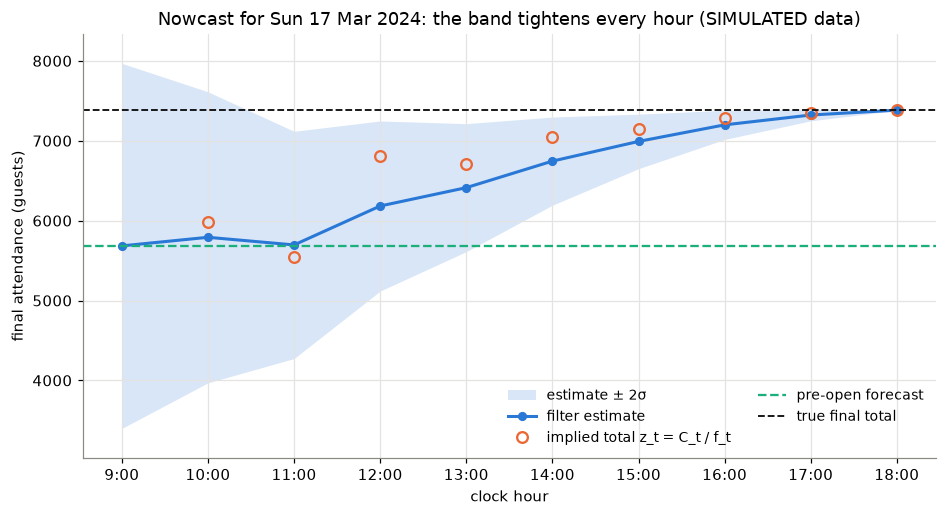

In [10]:
def plot_day(ax, table, forecast, truth, title=None, show_z=True, legend=True):
    # One day's nowcast: estimate with ±2σ band, implied totals, forecast and truth.
    hrs = table.index.to_numpy()
    est, sd = table["x"].to_numpy(), table["sd"].to_numpy()
    ax.fill_between(hrs, est - 2 * sd, est + 2 * sd, color=COLORS["estimate"], alpha=0.18, lw=0,
                    label="estimate ± 2σ")
    ax.plot(hrs, est, color=COLORS["estimate"], marker="o", label="filter estimate")
    if show_z:
        ax.plot(hrs, table["z"], ls="none", marker="o", mfc="none", mew=1.5, ms=7,
                color=COLORS["measurement"], label="implied total z_t = C_t / f_t")
    ax.axhline(forecast, color=COLORS["forecast"], ls="--", lw=1.5, label="pre-open forecast")
    ax.axhline(truth, color=COLORS["truth"], ls="--", lw=1.2, label="true final total")
    # Fit the y-range to the band, forecast and truth (early z_t can be far off).
    lo = min(np.nanmin(est - 2 * sd), forecast, truth)
    hi = max(np.nanmax(est + 2 * sd), forecast, truth)
    pad = 0.08 * (hi - lo)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xticks(hrs)
    ax.set_xticklabels([f"{h}:00" for h in hrs])
    if title:
        ax.set_title(title)
    if legend:
        ax.legend(loc="lower right", ncol=2, fontsize=9)

fig, ax = plt.subplots(figsize=(10, 5))
plot_day(ax, one_day, today.forecast, today.attendance,
         title=f"Nowcast for {DAY:%a %d %b %Y}: the band tightens every hour (SIMULATED data)")
ax.set_xlabel("clock hour")
ax.set_ylabel("final attendance (guests)")
plt.show()

The forecast missed by about 1,700 guests. By 14:00 the filter has closed about
60% of that gap, and by 15:00 it is within 5% of the truth. That is the practical
payoff: staffing, food and parking can be adjusted in the early afternoon, not after
closing.

**An honest flaw:** at 13:00–14:00 the true total sits *just outside* the ±2σ band.
The filter is overconfident. The early implied totals were all low *for the same
reason* (a late-arriving Sunday crowd), but the filter treats each hour's error as
independent luck, so it believes they confirm each other. Notebook 03 measures how
often this happens, and notebook 04 fixes the cause by estimating the day's pace.

## 7. Many days

The same loop, packaged as `runner.nowcast_days`, runs over every 2024 day. (The
first four weeks of 2022 have no forecast yet and are not part of the test anyway.)
Below are six days from the test year, with forecasts that were too high, too low
and about right.

**Thu 13 Jun** is a wet-season storm day: early counts point *above* the forecast,
the estimate rises, then a 13:00 storm stops arrivals and the implied totals fall
back. The filter follows, but for a few hours the band misses the truth. With `Q = 0`
the filter assumes nothing can change during the day. Notebook 03 tests whether
`Q > 0` helps.

366 test days filtered


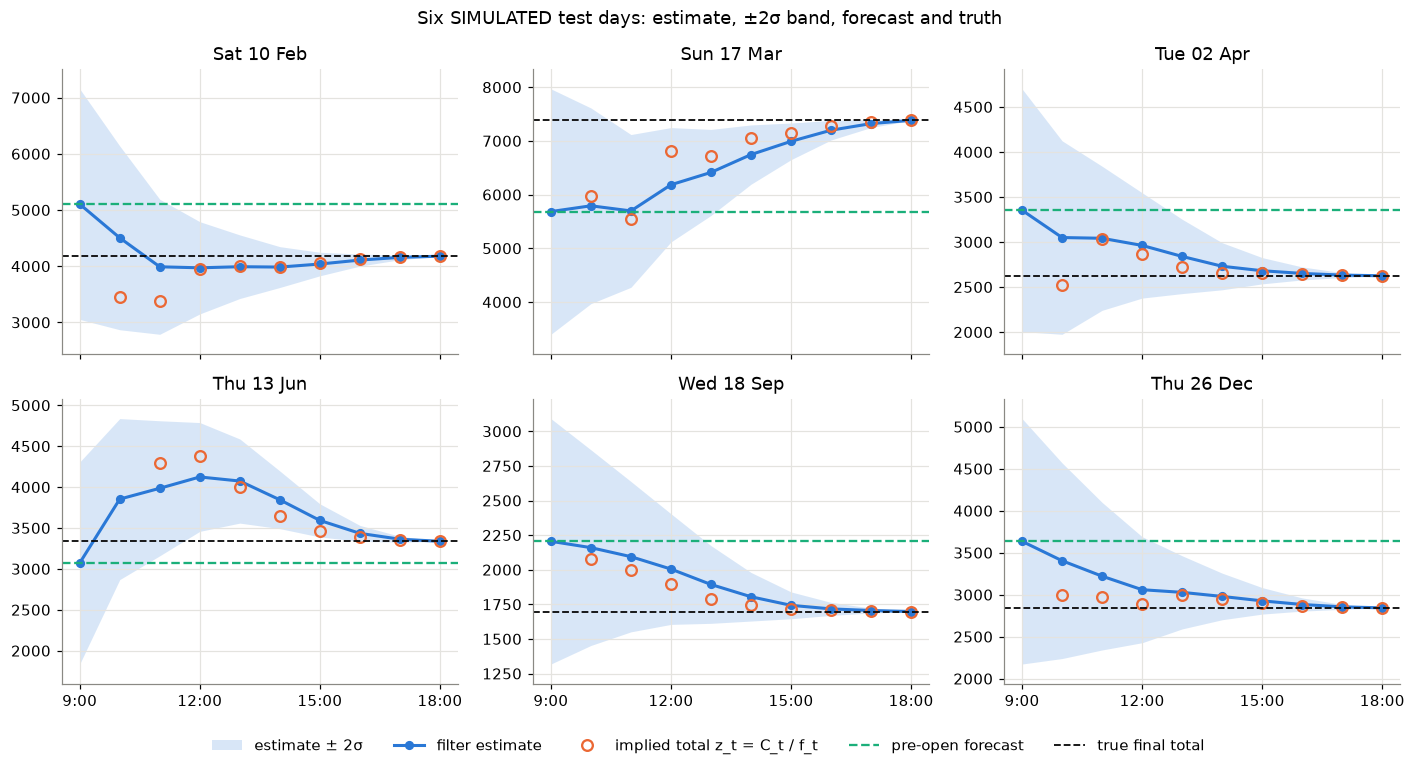

In [11]:
test_days = daily[~is_train].dropna()
results = nowcast_days(hourly, test_days, f, R, q=0.0, min_share=MIN_SHARE)
results["sd"] = np.sqrt(results["P"])
print(f"{test_days.shape[0]} test days filtered")

examples = ["2024-02-10", "2024-03-17", "2024-04-02", "2024-06-13", "2024-09-18", "2024-12-26"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for ax, d in zip(axes.flat, examples):
    r = results[results.visit_date == d].set_index("hour")
    pre = pd.DataFrame({"x": [r.forecast.iloc[0]], "sd": [np.sqrt(test_days.set_index("visit_date").P0[d])],
                        "z": [np.nan]}, index=[9])
    plot_day(ax, pd.concat([pre, r[["x", "sd", "z"]]]), r.forecast.iloc[0], r.truth.iloc[0],
             title=pd.Timestamp(d).strftime("%a %d %b"), legend=False)
    ax.set_xticks([9, 12, 15, 18])
    ax.set_xticklabels(["9:00", "12:00", "15:00", "18:00"])
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
fig.suptitle("Six SIMULATED test days: estimate, ±2σ band, forecast and truth")
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

A first look at the whole test year: the **mean absolute error** (MAE) by hour, for the
forecast alone and for the filter. The forecast never changes during the day, so its
error is flat. Notebook 03 does this scoring properly and tunes the knobs.

In [12]:
results["fc_err"] = (results.forecast - results.truth).abs()
results["kf_err"] = (results.x - results.truth).abs()
summary = results.groupby("hour")[["fc_err", "kf_err"]].mean().round(0)
summary.columns = ["MAE forecast only", "MAE filtered"]
summary

,MAE forecast only,MAE filtered
hour,,
10,568.0,455.0
11,568.0,448.0
12,568.0,424.0
13,568.0,354.0
14,568.0,251.0
15,568.0,146.0
16,568.0,69.0
17,568.0,22.0
18,568.0,0.0


## Summary

**What was built**

* A SQL-backed data layer (`nowcast/db.py`, `nowcast/schema.sql`) where every row
  carries `source = simulation | production`; this notebook reads one source via `SOURCE`.
* A **simulated** Tampa, FL park (`nowcast/simulate.py`): Florida seasons, weather,
  US/FL holidays, random early/late crowds and wet-season afternoon storms.
* The 1D nowcast: prior from a same-weekday forecast, measurements `z_t = C_t / f_t`,
  empirical relative `R_t`, and a guard for small `f_t`.

**Decisions made**

* `f_t` is one average curve across all days (notebook 03 tests separate
  weekend/holiday curves).
* `R_t` is **relative**: `(s_t × x⁻)²`, with `s_t` measured on 2022–23.
* The prior variance uses the forecast's historical relative error (±20%).
* Train on 2022–23, test on 2024.

**What to notice**

* The gain *rises* through the day, the opposite of notebook 01, because later
  measurements are much less noisy.
* By 18:00 the error is zero by construction: the closing count *is* the final total.
  The useful window is roughly 10:00–15:00.

**Next, notebook 03:** tune `Q` and the `R_t` scheme, score error by hour properly,
and check whether the ±2σ band really contains the truth 95% of the time.